# Forecasting every product with one XGBoost model

So far we've forecast a single product (store 1, item 1). A real business needs forecasts for
**every** product in **every** store, which here means 10 stores x 50 items = **500 separate sales histories**.

We could train 500 separate models, but instead we train **one model on all 500 histories together**.
That has two benefits:
- The model learns patterns shared across products (such as "Sundays are busy everywhere"),
  from 500 times more data than one product alone.
- There's only one model to maintain instead of 500.

We give the model `store` and `item` as features, so it can still learn what's different about each one.

In [1]:
# Install the libraries this notebook needs (only needed once)
%pip install xgboost scikit-learn

Note: you may need to restart the kernel to use updated packages.


## Step 1: Load the data and sort it

We sort by **store, then item, then date**. This puts each product's history together as one
continuous block of rows in date order:

| store | item | date |
|---|---|---|
| 1 | 1 | 2013-01-01 |
| 1 | 1 | 2013-01-02 |
| ... | ... | ... |
| 1 | 2 | 2013-01-01 |

The lag features in the next step look "back" a number of rows, so each product's rows
need to be together and in date order.

In [2]:
import time

import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor

# Load all 913,000 rows; parse_dates turns the "date" column into real dates
sales_df = pd.read_csv("../data/train.csv", parse_dates=["date"])

# .sort_values() with a list sorts by the first column, then the second within ties, and so on
sales_df = sales_df.sort_values(["store", "item", "date"]).reset_index(drop=True)

# Lags count rows, not calendar days, so every store-item needs exactly one row per day.
# .groupby(["store", "item"]).size() counts the rows in each of the 500 groups.
rows_per_product = sales_df.groupby(["store", "item"]).size()
days_in_range = (sales_df["date"].max() - sales_df["date"].min()).days + 1
print("Rows:", len(sales_df))
print("Store-item combinations:", len(rows_per_product))
print("Every combination has one row per day:", (rows_per_product == days_in_range).all())

Rows: 913000
Store-item combinations: 500
Every combination has one row per day: True


## Step 2: Create the features

**Calendar features** (`day_of_week`, `month`, `year`) come straight from the date, as before.

**`store` and `item`** are already columns. Using them as features tells the model *which*
product a row belongs to, so it can learn, for example, that item 15 sells far more than item 5.

**Past-sales features** (`lag_7`, `lag_14`, `lag_365`, `rolling_mean_7`) need extra care now.
All 500 products sit in one long table, so a plain `.shift(7)` would slide values across the
boundary between products. The first week of item 2 would get sales from the last week of item 1,
which is wrong.

The fix is **`groupby`**: it splits the table into one group per store-item combination,
runs the calculation inside each group separately, and puts the results back in the original row order.
Each product's first 7 days correctly get "missing" for `lag_7` instead of borrowing another product's sales.

In [3]:
# --- Calendar features ---
sales_df["day_of_week"] = sales_df["date"].dt.dayofweek  # 0 = Monday, 6 = Sunday
sales_df["month"] = sales_df["date"].dt.month            # 1-12
sales_df["year"] = sales_df["date"].dt.year

# --- Group the rows by product ---
# .groupby(["store", "item"]) splits the table into 500 groups, one per store-item combination.
# Selecting ["sales"] means the calculations below only look at the sales column.
sales_by_product = sales_df.groupby(["store", "item"])["sales"]

# --- Lag features ---
# .shift(n) moves values DOWN by n rows, so each row gets the value from n rows (= n days) earlier.
# Called on a groupby, the shift happens inside each group separately, so values never cross from
# one product into another. Each group's first n rows get NaN (missing).
sales_df["lag_7"] = sales_by_product.shift(7)
sales_df["lag_14"] = sales_by_product.shift(14)
sales_df["lag_365"] = sales_by_product.shift(365)

# --- Rolling average ---
# .rolling(7).mean() averages a moving "window" of 7 rows. On its own, the window includes today,
# so we .shift(1) first to cover only the 7 days BEFORE today.
# .transform() runs this calculation on each group and returns one value per original row,
# lined up with sales_df, so we can store it as a new column.
sales_df["rolling_mean_7"] = sales_by_product.transform(lambda group_sales: group_sales.shift(1).rolling(7).mean())

feature_columns = ["day_of_week", "month", "year", "store", "item",
                   "lag_7", "lag_14", "lag_365", "rolling_mean_7"]

# Sanity check: item 2's first rows should have NaN lags, NOT values borrowed from item 1
sales_df[(sales_df["store"] == 1) & (sales_df["item"] == 2)][["store", "item", "date", "sales", "lag_7"]].head(9)

,store,item,date,sales,lag_7
1826,1,2,2013-01-01,33,NaN
1827,1,2,2013-01-02,43,NaN
1828,1,2,2013-01-03,23,NaN
1829,1,2,2013-01-04,18,NaN
1830,1,2,2013-01-05,34,NaN
1831,1,2,2013-01-06,38,NaN
1832,1,2,2013-01-07,27,NaN
1833,1,2,2013-01-08,28,33.0
1834,1,2,2013-01-09,34,43.0


## Step 3: Remove rows with missing features

Each product's first 365 days have no `lag_365` value, because there is no "last year" yet.
We drop those rows, which removes the first year (2013) for all 500 products.

In [4]:
rows_before = len(sales_df)

# .dropna(subset=[...]) removes rows with a missing value in any of those columns
model_df = sales_df.dropna(subset=feature_columns).reset_index(drop=True)

print(f"Rows before: {rows_before:,}")
print(f"Rows after:  {len(model_df):,} ({rows_before - len(model_df):,} dropped)")
print("Data now starts on:", model_df["date"].min().date())

Rows before: 913,000
Rows after:  730,500 (182,500 dropped)
Data now starts on: 2014-01-01


## Step 4: Split into training and test sets by date

We pick **one cutoff date** that applies to every product: the test set is the final **8 weeks**
(the same period as the single-product notebooks), and everything before it is training.
Using the same date for all products means the model never trains on any day from the test period,
for any product.

**Caveat (same as the single-product XGBoost notebook).** For test days, the lag and rolling
features are calculated from **real** sales, some of which fall inside the test period itself.
So the model gets fresh real data during the test period, which makes it closer to a
few-days-ahead forecast than a true 8-weeks-ahead forecast like Prophet's.

In [5]:
# One shared cutoff: the test set starts 8 weeks before the last date
last_date = model_df["date"].max()
test_start_date = last_date - pd.Timedelta(weeks=8) + pd.Timedelta(days=1)

train_df = model_df[model_df["date"] < test_start_date]
test_df = model_df[model_df["date"] >= test_start_date].copy()

# X = inputs (features), y = what we want to predict (sales)
X_train, y_train = train_df[feature_columns], train_df["sales"]
X_test, y_test = test_df[feature_columns], test_df["sales"]

print(f"Training set: {len(train_df):,} rows ({train_df['date'].min().date()} to {train_df['date'].max().date()})")
print(f"Test set:     {len(test_df):,} rows ({test_df['date'].min().date()} to {test_df['date'].max().date()})")
print(f"Test rows per product: {len(test_df) // 500} days x 500 products")

Training set: 702,500 rows (2014-01-01 to 2017-11-05)
Test set:     28,000 rows (2017-11-06 to 2017-12-31)
Test rows per product: 56 days x 500 products


## Step 5: Train one XGBoost model on all products

Same kind of model as before, but trained on about 700,000 rows instead of about 1,400.
We time the training so you can see the cost of the bigger dataset.

**Approximate training time:** About 15 seconds for training on the laptop this notebook was tested on (13 seconds, plus a few seconds to build the features in Step 2). That's much longer than the single-product model (well under a second), but still quick, because XGBoost uses every CPU core. The exact time depends on your
computer, and the cell below prints the real time for your run.

In [7]:
model = XGBRegressor(
    n_estimators=500,    # how many trees to build
    learning_rate=0.05,  # how much each tree is allowed to correct; small = steadier learning
    max_depth=6,         # a bit deeper than the single-product model: there are more patterns to learn
    n_jobs=-1,           # use all CPU cores to train faster
    random_state=42,     # same result every run
)

# time.perf_counter() reads a stopwatch; subtracting two readings gives the elapsed seconds
start_time = time.perf_counter()
model.fit(X_train, y_train)
training_seconds = time.perf_counter() - start_time

print(f"Model trained in {training_seconds:.1f} seconds.")

Model trained in 10.9 seconds.


## Step 6: Predict the test period and measure overall accuracy

We predict all 28,000 test rows (56 days x 500 products) and calculate MAPE and RMSE with the
same formulas as before. The results cover every prediction together.

In [8]:
# Store predictions as a column in test_df, so each prediction sits next to its store, item and date
test_df["predicted_sales"] = model.predict(X_test)

# Error for every row: prediction minus reality
test_df["error"] = test_df["predicted_sales"] - test_df["sales"]

# Percentage error for every row (used for MAPE). Days with 0 real sales would divide by zero,
# so we leave them out: .where() keeps a value when the condition is True and puts NaN otherwise,
# and .mean() skips NaN automatically.
test_df["abs_pct_error"] = (test_df["error"].abs() / test_df["sales"]).where(test_df["sales"] != 0) * 100

overall_mape = test_df["abs_pct_error"].mean()
overall_rmse = (test_df["error"] ** 2).mean() ** 0.5

print(f"Overall MAPE: {overall_mape:.2f}%")
print(f"Overall RMSE: {overall_rmse:.2f} units")
print(f"(Days left out of MAPE for having 0 sales: {(test_df['sales'] == 0).sum()})")

Overall MAPE: 14.73%
Overall RMSE: 8.07 units
(Days left out of MAPE for having 0 sales: 0)


## Step 7: Accuracy by store

One overall number can hide problems. Here we calculate MAPE separately for each store
to see whether the model is equally good everywhere or struggles with particular stores.

In [9]:
# .groupby("store")["abs_pct_error"].mean() averages the percentage errors within each store.
# .sort_values() orders the stores from best (lowest MAPE) to worst.
mape_by_store = test_df.groupby("store")["abs_pct_error"].mean().sort_values()

print("MAPE by store (best to worst):")
print(mape_by_store.round(2).to_string())
print(f"\nGap between best and worst store: {mape_by_store.max() - mape_by_store.min():.2f} percentage points")

MAPE by store (best to worst):
store
2     12.66
8     12.76
3     13.25
10    13.37
9     14.15
4     14.21
1     15.14
6     16.29
5     17.47
7     17.97

Gap between best and worst store: 5.31 percentage points


## Step 8: Compare with the single-product models

The first two rows are typed in from the earlier notebooks. The third row covers **all 500 products**,
so it isn't a like-for-like comparison:
- **MAPE** is a *percentage*. Many products sell far more than store 1 / item 1 (around 19 units a day),
  and a miss of 5 units is a smaller percentage of 60 sales than of 19. So high-volume products
  pull the overall MAPE **down**.
- **RMSE** is in *units*. The same high-volume products have bigger misses in units, so the overall RMSE goes **up**.

That's why we also print this model's score on **store 1, item 1 alone**, which can be compared
directly with the first two rows.

In [11]:
comparison_df = pd.DataFrame([
    {"model": "Prophet - Tuned (single product)", "MAPE (%)": 23.19, "RMSE": 4.55},
    {"model": "XGBoost (single product)", "MAPE (%)": 25.20, "RMSE": 4.92},
    {"model": "XGBoost (all products combined)", "MAPE (%)": overall_mape, "RMSE": overall_rmse},
])
print("Comparison on the same 8-week test period (lower is better):\n")
print(comparison_df.round(2).to_string(index=False))

# Like-for-like: this model's accuracy on store 1 / item 1 only
product_1_1 = test_df[(test_df["store"] == 1) & (test_df["item"] == 1)]
print(f"\nAll-products model on store 1 / item 1 only: "
      f"MAPE {product_1_1['abs_pct_error'].mean():.2f}%, "
      f"RMSE {(product_1_1['error'] ** 2).mean() ** 0.5:.2f}")

Comparison on the same 8-week test period (lower is better):

                           model  MAPE (%)  RMSE
Prophet - Tuned (single product)     23.19  4.55
        XGBoost (single product)     25.20  4.92
 XGBoost (all products combined)     14.73  8.07

All-products model on store 1 / item 1 only: MAPE 25.58%, RMSE 4.81


## Step 9: Which features mattered most?

**Feature importance** scores how much each feature helped the model make accurate predictions.
A feature earns credit every time a tree uses it to split the data and the split improves the predictions.
The scores add up to 1, so you can read them as each feature's share of the credit.

You might expect **`store`** and **`item`** to matter a lot, because products sell at very
different volumes. In practice they usually score near zero. The recent-sales features
(`rolling_mean_7`, `lag_7`) already tell the model how much this product has been selling, which
is more precise than a product ID number. So once the model knows recent sales, knowing *which*
product it is adds almost nothing.

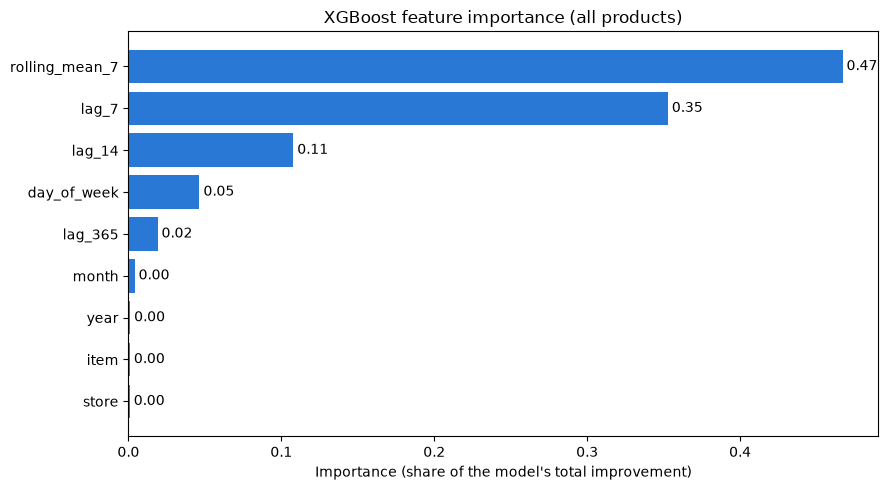

In [12]:
# One score per feature, sorted so the most important ends up at the top of the chart
feature_importance = pd.Series(model.feature_importances_, index=feature_columns).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(feature_importance.index, feature_importance.values, color="#2a78d6")
ax.set_title("XGBoost feature importance (all products)")
ax.set_xlabel("Importance (share of the model's total improvement)")

# Write each score at the end of its bar
for position, value in enumerate(feature_importance.values):
    ax.text(value, position, f" {value:.2f}", va="center")

plt.tight_layout()
plt.show()

## Step 10: Spot-check 3 random products

The overall MAPE is an average over 500 products. To check that individual forecasts look sensible,
we pick 3 store-item combinations at random and plot their actual and predicted sales
over the 8-week test period.

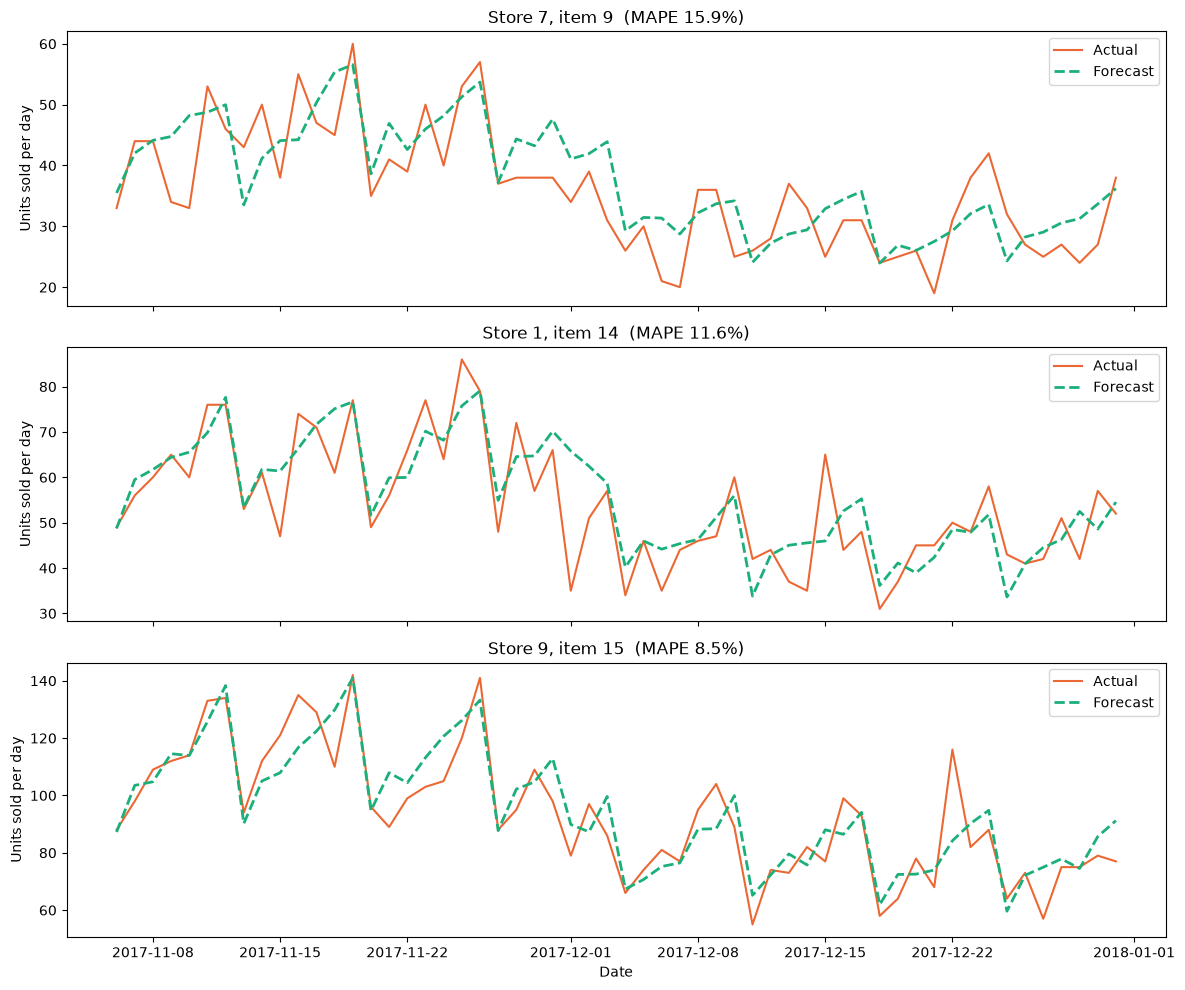

In [13]:
# .drop_duplicates() gives the list of unique store-item pairs; .sample(3) picks 3 at random.
# random_state=7 makes it pick the same 3 every time; change the number to see different ones.
sample_products = test_df[["store", "item"]].drop_duplicates().sample(3, random_state=7)

ACTUAL_COLOR, FORECAST_COLOR = "#eb6834", "#1baf7a"  # same colours as the earlier notebooks

# One chart per product, stacked vertically; sharex=True lines up the date axes
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# zip() pairs up each chart with one sampled product.
# .itertuples() loops over the rows of a table, giving access to row.store and row.item.
for ax, product in zip(axes, sample_products.itertuples()):
    product_test = test_df[(test_df["store"] == product.store) & (test_df["item"] == product.item)]
    product_mape = product_test["abs_pct_error"].mean()

    ax.plot(product_test["date"], product_test["sales"], color=ACTUAL_COLOR, linewidth=1.5, label="Actual")
    ax.plot(product_test["date"], product_test["predicted_sales"], color=FORECAST_COLOR, linewidth=2,
            linestyle="--", label="Forecast")
    ax.set_title(f"Store {product.store}, item {product.item}  (MAPE {product_mape:.1f}%)")
    ax.set_ylabel("Units sold per day")
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()